# Notebook 05: LOSO Validation
Opx ML Thermobarometer
Author: [Your name]
Date: 2026-04-04

This notebook performs leave-one-study-out validation to assess model generalization across different publications.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from config import (ROOT, DATA_RAW, DATA_PROC, DATA_SPLITS, DATA_NATURAL,
                    MODELS, FIGURES, RESULTS, LOGS, EXPETDB)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import ast
import warnings
warnings.filterwarnings('ignore')

## 5.1 Load data and prepare for LOSO

In [2]:
# Load opx-liq dataset from parquet (saved by NB03)
df_liq = pd.read_parquet(DATA_PROC / 'opx_clean_opx_liq.parquet')

OPX_FEAT = ['SiO2','Al2O3','FeO_total','MgO','CaO','Mg_num','Al_IV','Al_VI','En_frac','Fs_frac','Wo_frac','MgTs']
LIQ_OXIDES = ['SiO2','TiO2','Al2O3','FeO','MgO','CaO','Na2O','K2O']
liq_feat = [f'liq_{o}' for o in LIQ_OXIDES] + ['liq_Mg_num']
ALL_FEAT = OPX_FEAT + liq_feat

X = df_liq[ALL_FEAT].fillna(0).values
y_T = df_liq['T_C'].values
y_P = df_liq['P_kbar'].values
groups = df_liq['Citation'].values

print(f'LOSO dataset: {len(df_liq)} samples, {len(np.unique(groups))} studies')

LOSO dataset: 609 samples, 93 studies


## 5.2 Run LOSO validation

In [3]:
results_df = pd.read_csv(RESULTS / 'nb03_results_all.csv')

MODEL_CLASSES = {
    'RF':  RandomForestRegressor,
    'ERT': ExtraTreesRegressor,
    'XGB': XGBRegressor,
    'GB':  GradientBoostingRegressor,
}

logo = LeaveOneGroupOut()
loso_rows = []

for model_name, ModelClass in MODEL_CLASSES.items():
    print(f'\n=== LOSO: {model_name} ===')

    params_T = ast.literal_eval(results_df[
        (results_df['model'] == model_name) &
        (results_df['target'] == 'T_C') &
        (results_df['model_type'] == 'opx_liq')
    ]['best_params'].values[0])

    params_P = ast.literal_eval(results_df[
        (results_df['model'] == model_name) &
        (results_df['target'] == 'P_kbar') &
        (results_df['model_type'] == 'opx_liq')
    ]['best_params'].values[0])

    has_njobs = 'n_jobs' in ModelClass().get_params()

    for train_idx, test_idx in logo.split(X, y_T, groups=groups):
        if len(test_idx) < 2:
            continue

        study = df_liq.iloc[test_idx]['Citation'].iloc[0]

        for target_name, y, params in [('T_C', y_T, params_T), ('P_kbar', y_P, params_P)]:
            kw = dict(n_jobs=-1) if has_njobs else {}
            mdl = ModelClass(**params, random_state=42, **kw)
            mdl.fit(X[train_idx], y[train_idx])
            pred = mdl.predict(X[test_idx])
            rmse = np.sqrt(mean_squared_error(y[test_idx], pred))
            loso_rows.append({
                'model': model_name,
                'target': target_name,
                'study': study,
                'n_test': len(test_idx),
                'rmse': rmse,
                'mean_y_held_out': np.mean(y[test_idx]),
            })

    t_rmses = [r['rmse'] for r in loso_rows if r['model'] == model_name and r['target'] == 'T_C']
    p_rmses = [r['rmse'] for r in loso_rows if r['model'] == model_name and r['target'] == 'P_kbar']
    print(f"  T median RMSE: {np.median(t_rmses):.2f} C")
    print(f"  P median RMSE: {np.median(p_rmses):.2f} kbar")

loso_df = pd.DataFrame(loso_rows)
loso_df.to_csv(RESULTS / 'nb05_loso_all.csv', index=False)

# Also save RF-only for backward compat
loso_df_T = loso_df[(loso_df['model'] == 'RF') & (loso_df['target'] == 'T_C')].copy()
loso_df_P = loso_df[(loso_df['model'] == 'RF') & (loso_df['target'] == 'P_kbar')].copy()
loso_df_T.to_csv(RESULTS / 'nb05_loso_T.csv', index=False)
loso_df_P.to_csv(RESULTS / 'nb05_loso_P.csv', index=False)

print(f'\nSaved {len(loso_df)} LOSO rows to results/')


=== LOSO: RF ===
  T median RMSE: 58.43 C
  P median RMSE: 3.05 kbar

=== LOSO: ERT ===
  T median RMSE: 59.62 C
  P median RMSE: 3.13 kbar

=== LOSO: XGB ===
  T median RMSE: 67.47 C
  P median RMSE: 3.02 kbar

=== LOSO: GB ===
  T median RMSE: 60.95 C
  P median RMSE: 2.97 kbar

Saved 592 LOSO rows to results/


## 5.3 Create LOSO box plot (Fig 6)

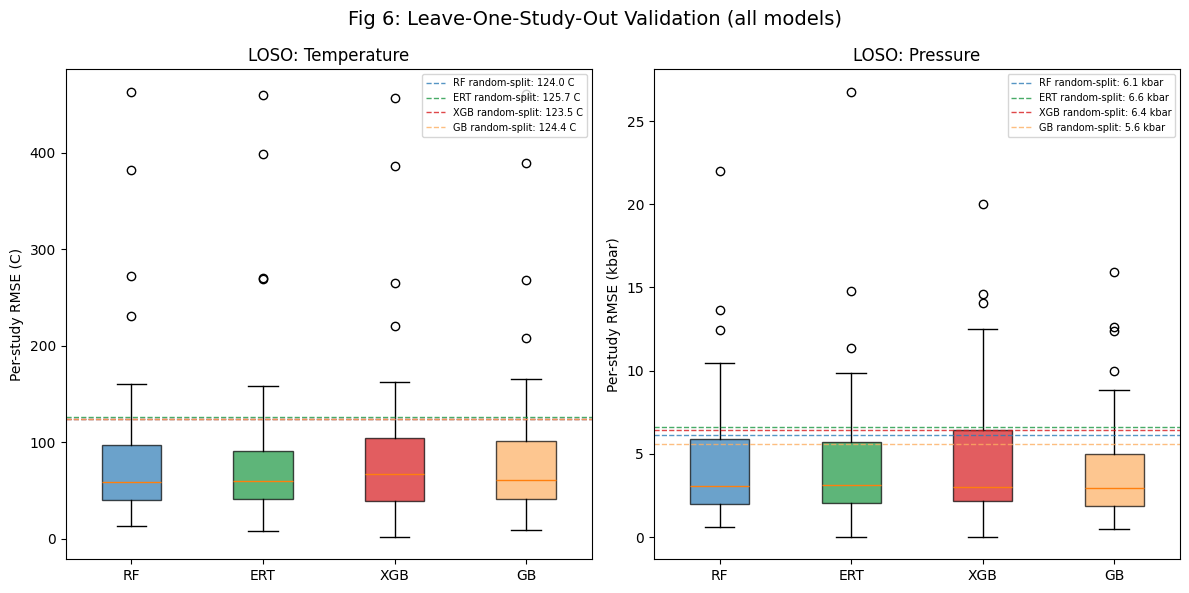

Saved fig06_loso_boxplot.png

Notebook 05 complete.


In [4]:
models_order = ['RF', 'ERT', 'XGB', 'GB']
colors = ['#2c7bb6', '#1a9641', '#d7191c', '#fdae61']

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, target, unit in [(axes[0], 'T_C', 'C'), (axes[1], 'P_kbar', 'kbar')]:
    data = [loso_df[(loso_df['model'] == m) & (loso_df['target'] == target)]['rmse'].values
            for m in models_order]
    bp = ax.boxplot(data, labels=models_order, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for m, color in zip(models_order, colors):
        rs = results_df[(results_df['model'] == m) &
                        (results_df['target'] == target) &
                        (results_df['model_type'] == 'opx_liq')]['rmse_test'].values
        if len(rs):
            ax.axhline(rs[0], color=color, ls='--', lw=1, alpha=0.8,
                       label=f'{m} random-split: {rs[0]:.1f} {unit}')
    ax.set_ylabel(f'Per-study RMSE ({unit})')
    title = 'Temperature' if target == 'T_C' else 'Pressure'
    ax.set_title(f'LOSO: {title}')
    ax.legend(fontsize=7)

plt.suptitle('Fig 6: Leave-One-Study-Out Validation (all models)', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(FIGURES / 'fig06_loso_boxplot.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('Saved fig06_loso_boxplot.png')
print('\nNotebook 05 complete.')